In [35]:
# Library
import pandas as pd
import os
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data Collection

In [22]:
df = pd.read_csv('datasets/dataset_spotify_tracks.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Preprocessing Data

In [23]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Missing Value

In [24]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [25]:
df = df.dropna()
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Data Duplicate

In [26]:
print("Jumlah duplikat identik:", df.duplicated().sum())

Jumlah duplikat identik: 0


## Normalize Data

In [28]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean = df_clean.drop(columns=["unnamed:_0"], errors="ignore")

text_cols = ["track_id", "artists", "album_name", "track_name", "track_genre"]

for col in text_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()

df_clean["explicit"] = df_clean["explicit"].astype(bool)
df_clean["track_genre"] = df_clean["track_genre"].astype("category")

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   track_id          113999 non-null  string  
 1   artists           113999 non-null  string  
 2   album_name        113999 non-null  string  
 3   track_name        113999 non-null  string  
 4   popularity        113999 non-null  int64   
 5   duration_ms       113999 non-null  int64   
 6   explicit          113999 non-null  bool    
 7   danceability      113999 non-null  float64 
 8   energy            113999 non-null  float64 
 9   key               113999 non-null  int64   
 10  loudness          113999 non-null  float64 
 11  mode              113999 non-null  int64   
 12  speechiness       113999 non-null  float64 
 13  acousticness      113999 non-null  float64 
 14  instrumentalness  113999 non-null  float64 
 15  liveness          113999 non-null  float64 
 16  valence

# EDA

## Customer Side

### Is audio features (energy, danceability, valence, tempo) are most strongly correlated with a song’s popularity?

popularity          1.000000
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_ms        -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64

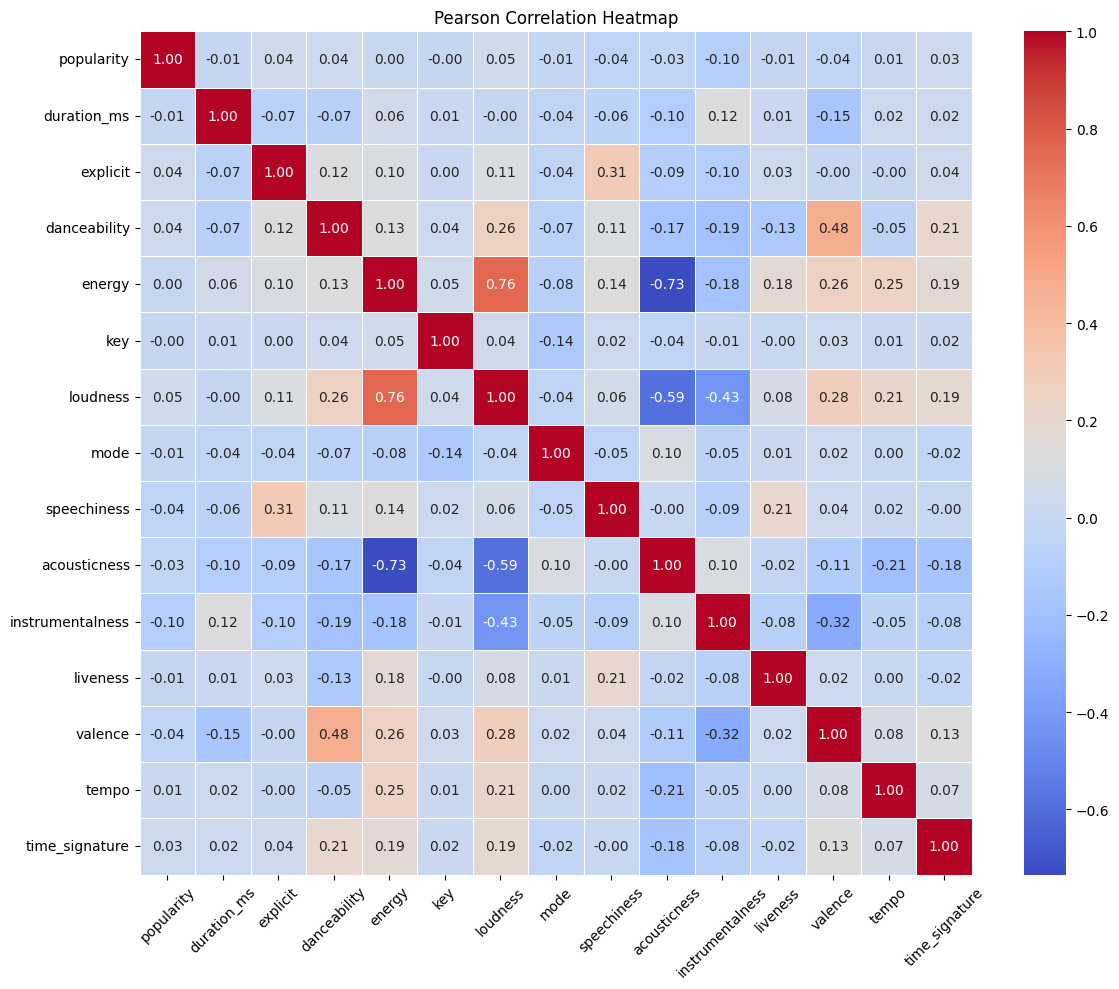

In [34]:
numeric_df = df_clean.select_dtypes(include=["number", "bool"])

correlation_matrix = numeric_df.corr(method="pearson")

popularity_corr = correlation_matrix["popularity"].sort_values(ascending=False)
display(popularity_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Insight:

Semua korelasi dengan popularitas sangat rendah. Ini sendiri adalah temuan penting:
popularitas lagu tidak bisa diprediksi hanya dari fitur audio-nya.
Yang lebih menarik adalah korelasi antar fitur:

- energy ↔ loudness: +0.76 (sangat kuat) — lagu keras = lagu berenergi
- energy ↔ acousticness: -0.73 (sangat kuat negatif) — lagu akustik cenderung tenang
- danceability ↔ valence: +0.48 — lagu yang enak digerakin cenderung terasa positif/happy

Interpretasi bisnis:
Lagu populer di Spotify cenderung memiliki **profil audio: energy tinggi + loudness tinggi

- acousticness rendah** — identik dengan karakteristik pop dan hip-hop mainstream.
Ini bukan "formula ajaib", tapi preferensi mayoritas pendengar streaming global.

### Are shorter songs more popular in the streaming era?

In [36]:
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

sample_df = df_clean.sample(5000, random_state=42)

fig = px.scatter(
    sample_df,
    x="duration_min",
    y="popularity",
    hover_data=["track_name", "artists", "track_genre"],
    trendline="ols",
    title="Does Shorter Song Duration Relate to Higher Popularity?",
    labels={
        "duration_min": "Duration (minutes)",
        "popularity": "Popularity"
    },
    opacity=0.4
)

fig.show()

Insight:

Mayoritas lagu dengan popularitas tinggi berada di rentang durasi 2–5 menit.
Di atas 8 menit, popularitas menurun drastis. Trendline keseluruhan hampir flat
(korelasi sangat lemah: r ≈ -0.01), namun distribusi datanya bercerita lain.

Interpretasi bisnis:

Di era streaming dan short-form content, pendengar cepat berpindah lagu.
Durasi optimal 3–4 menit memberi ruang untuk hook, verse, chorus, dan bridge
tanpa kehilangan perhatian pendengar.

### Do songs with explicit lyrics have different levels of popularity compared to those without?

In [38]:
fig = px.box(
    df_clean,
    x="explicit",
    y="popularity",
    color="explicit",
    title="Popularity Distribution: Explicit vs Non-Explicit Songs",
    labels={
        "explicit": "Explicit Lyrics",
        "popularity": "Popularity"
    }
)

fig.show()

Insight:

Lagu explicit memiliki median popularitas sedikit lebih tinggi (37 vs 34),
namun dengan sebaran yang lebih lebar. Ini menunjukkan pola "boom or bust" —
lagu explicit berpotensi lebih viral, tapi juga lebih banyak yang tenggelam.

Interpretasi bisnis:

Konten eksplisit bukan jaminan sukses, tapi genre yang dominan menggunakannya
(hip-hop, rap) memang cenderung mendominasi chart streaming global.